<a href="https://colab.research.google.com/github/takeonakamura6-design/lp/blob/main/Introdu%C3%A7%C3%A3o%20a%20manipula%C3%A7%C3%A3o%20de%20dados%20em%20Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introdução a manipulação de dados em Pandas

Iniciando Experimento Prático...

--- TABELA 1: RESULTADOS ESTATÍSTICOS DO EXPERIMENTO ---
     Status      Média    Mínimo     Máximo  Frequência
     Alerta 100.050819 42.450167 148.646395        2057
    Crítico  99.008622 55.852877 146.183212        1044
Operacional 100.088428 41.163996 158.893566        6899


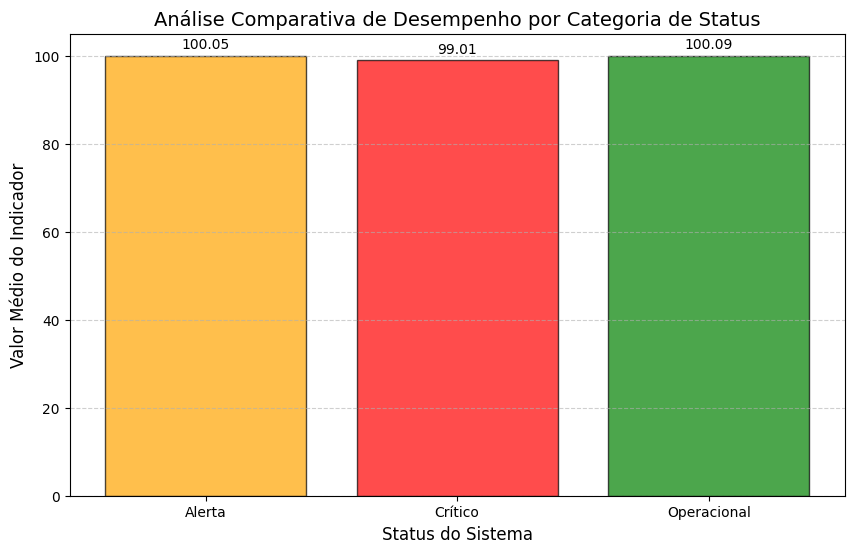


[INFO] Gráfico salvo com sucesso como 'grafico.png'.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

def gerar_dataset_experimental(n_amostras=10000):
    """Gera dados sintéticos para o experimento científico."""
    np.random.seed(42)
    inicio = datetime(2023, 1, 1)
    datas = [inicio + timedelta(hours=i) for i in range(n_amostras)]

    dados = {
        'timestamp': datas,
        'valor_indicador': np.random.normal(loc=100, scale=15, size=n_amostras),
        'status': np.random.choice(['Operacional', 'Alerta', 'Crítico'], size=n_amostras, p=[0.7, 0.2, 0.1])
    }
    return pd.DataFrame(dados)

def processar_experimento(df):
    """Aplica filtros e extrai métricas estatísticas segmentadas."""
    # Filtragem de eventos críticos e alertas
    df_prioritario = df.loc[df['status'].isin(['Alerta', 'Crítico'])]

    # Extração de métricas comparativas
    resumo = df.groupby('status')['valor_indicador'].agg(['mean', 'min', 'max', 'count']).reset_index()
    resumo.columns = ['Status', 'Média', 'Mínimo', 'Máximo', 'Frequência']

    return resumo, df_prioritario

def gerar_visualizacao(resumo):
    """Gera o gráfico comparativo para o Short Paper."""
    plt.figure(figsize=(10, 6))
    colors = ['orange', 'red', 'green']

    bars = plt.bar(resumo['Status'], resumo['Média'], color=colors, alpha=0.7, edgecolor='black')
    plt.title('Análise Comparativa de Desempenho por Categoria de Status', fontsize=14)
    plt.ylabel('Valor Médio do Indicador', fontsize=12)
    plt.xlabel('Status do Sistema', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Adicionando rótulos de dados
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, round(yval, 2), ha='center', va='bottom')

    # Salvando para o Zenodo
    plt.savefig('grafico.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n[INFO] Gráfico salvo com sucesso como 'grafico.png'.")

# Execução do Ciclo Experimental
if __name__ == "__main__":
    print("Iniciando Experimento Prático...\n")

    # 1. Preparação dos dados
    raw_data = gerar_dataset_experimental()

    # 2. Processamento Analítico
    tabela_final, dados_filtrados = processar_experimento(raw_data)

    # 3. Exibição dos Resultados (Tabela para o Artigo)
    print("--- TABELA 1: RESULTADOS ESTATÍSTICOS DO EXPERIMENTO ---")
    print(tabela_final.to_string(index=False))

    # 4. Geração de Gráfico
    gerar_visualizacao(tabela_final)